# Practical 8

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearnex import patch_sklearn
patch_sklearn(verbose=False)

## Exercise 1: Introduction to simple text embeddings

In this exercise you will learn basic mathods to deal with text data. We will use with the famous `20newsgroups` dataset. It consists of a large collection of news posts across 20 topics. We will be using it to test some basic NLP techniques and train a multi-class classification model to predict the most likely topic for unseen news posts. 
For more information, check [the dataset description](https://scikit-learn.org/stable/datasets/real_world.html#the-20-newsgroups-text-dataset) and the [import function helper](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_20newsgroups.html)

### 1.0 Importing text data

We restrict the dataset to only 4 of the categories, for presentation simplicity.

In [2]:
categories = ['alt.atheism', 'soc.religion.christian', 'comp.graphics', 'sci.med']

In [3]:
from sklearn.datasets import fetch_20newsgroups

# Import training data
twenty_train = fetch_20newsgroups(subset='train',
    categories=categories, shuffle=True, random_state=42)

# Import test data
twenty_test = fetch_20newsgroups(subset='test',
    categories=categories, shuffle=True, random_state=42)
docs_test = twenty_test.data

Try to access from `twent_train` the categories you want to predict.

In [6]:
twenty_train.target_names

['alt.atheism', 'comp.graphics', 'sci.med', 'soc.religion.christian']

In [7]:
len(twenty_train.data)

2257

Try to access the first observation from the training data `twenty_train`. Consider using the `print()` function.

In [8]:
twenty_train.data[0]

'From: sd345@city.ac.uk (Michael Collier)\nSubject: Converting images to HP LaserJet III?\nNntp-Posting-Host: hampton\nOrganization: The City University\nLines: 14\n\nDoes anyone know of a good way (standard PC application/PD utility) to\nconvert tif/img/tga files into LaserJet III format.  We would also like to\ndo the same, converting to HPGL (HP plotter) files.\n\nPlease email any response.\n\nIs this the correct group?\n\nThanks in advance.  Michael.\n-- \nMichael Collier (Programmer)                 The Computer Unit,\nEmail: M.P.Collier@uk.ac.city                The City University,\nTel: 071 477-8000 x3769                      London,\nFax: 071 477-8565                            EC1V 0HB.\n'

In [9]:
print(twenty_train.data[0])

From: sd345@city.ac.uk (Michael Collier)
Subject: Converting images to HP LaserJet III?
Nntp-Posting-Host: hampton
Organization: The City University
Lines: 14

Does anyone know of a good way (standard PC application/PD utility) to
convert tif/img/tga files into LaserJet III format.  We would also like to
do the same, converting to HPGL (HP plotter) files.

Please email any response.

Is this the correct group?

Thanks in advance.  Michael.
-- 
Michael Collier (Programmer)                 The Computer Unit,
Email: M.P.Collier@uk.ac.city                The City University,
Tel: 071 477-8000 x3769                      London,
Fax: 071 477-8565                            EC1V 0HB.



In [10]:
twenty_train.target[0]

1

In [11]:
print(twenty_train.target_names[twenty_train.target[0]])

comp.graphics


In [12]:
twenty_train.target[0:10]

array([1, 1, 3, 3, 3, 3, 3, 2, 2, 2], dtype=int64)

### 1.1 Text vectorization example with Bag of words and TF-IDF

We want to train a simple multi-class ML classifier to predict the news topic. In order to do so, we must first vectorize the text data.

Here we perform basic text embedding using bag-of-words and TF-IDF.

Bag-of-words is the simplest *embedding* technique in which words are represented as one-hot encoded numeric vectors of word counts. The length of these vectors corresponds to the size of the vocabulary of the training corpus.
That is, each column $j$ in the resulting sparse matrix represents a word and and each row $i$ represents a different observation (i.e. document), and the coresonping entry in the matrix is the word count of how many times the word $j$ appears in document $i$.
See [CountVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html) for the scikit-learn implementation of the bag-of-words embedding and its many options.

TF-IDF uses the **same** one-hot encoding as traditional BOW, but transforms the simple counts to the relative word frequency, normalized by the inverse-document-frequency to account for frequently occurring words across all documents. 
The intuition is that not only the word's frequency in a given document indicates if that word represents the document well, but also how rare it is in other documents in comparison. 
See the [TfidfVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html) and [TfidfTransformer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfTransformer.html) scikit-learn classes for help.

For more information see
- https://scikit-learn.org/stable/modules/feature_extraction.html#text-feature-extraction

- https://en.wikipedia.org/wiki/Tf-idf

#### Way 1: Bag of words and TF-IDF separately

Here we perform the preprocessing in two steps. 
First, we create the predictor matrix `X_train_counts` using bag of words (`CountVectorizer`). Each column here represents a word and and each row represents a different observation, i.e., document. `CountVectorizer` counts how many times the word $j$ appears in document $i$. 

In [13]:
from sklearn.feature_extraction.text import CountVectorizer

count_vect = CountVectorizer(lowercase=True, min_df=1e-3)
#Some arguments: max_features=1500, min_df=5, max_df=0.999, ngram_range=(1,2), stop_words=nltk.stopwords.words('english')

X_train_counts = count_vect.fit_transform(twenty_train.data)

How many documents are there in the data sets? How many words?

In [14]:
X_train_counts.shape

(2257, 13105)

In [15]:
X_train_counts

<2257x13105 sparse matrix of type '<class 'numpy.int64'>'
	with 337814 stored elements in Compressed Sparse Row format>

In [16]:
X_train_counts[2,4]

0

Now create the predictor matrix `X_train_tfidf` using `TfidfTransformer`. What is the difference between `X_train_counts` and `X_train_tfidf`?

In [17]:
from sklearn.feature_extraction.text import TfidfTransformer

tfidf_transformer = TfidfTransformer()

X_train_tfidf = tfidf_transformer.fit_transform(X_train_counts)

In [18]:
X_train_tfidf.shape

(2257, 13105)

In [19]:
X_train_tfidf[0, 10]

0.0

#### Way 2: both at once
Here we repeat the two steps above in one single step, using `TfidfVectorizer`.

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidfconverter = TfidfVectorizer(lowercase=True, min_df=1e-3)#max_features=1500, min_df=5, max_df=0.7, ngram_range=(1,2)

X_train_tfidf = tfidfconverter.fit_transform(twenty_train.data)

In [21]:
X_train_tfidf.shape

(2257, 13105)

### 1.2 Text classification

Fit a logistic regression model on the vectorized data set. Evaluate the test accuracy.

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [23]:
clf = LogisticRegression(max_iter=int(1e4))

clf.fit(X_train_tfidf, twenty_train.target)

LogisticRegression(max_iter=10000)

In [24]:
X_test_tfidf = tfidfconverter.transform(twenty_test.data)
X_test_tfidf.shape

(1502, 13105)

In [25]:
y_hat = clf.predict(X_test_tfidf)
accuracy_score(twenty_test.target, y_hat)

0.9014647137150466

Repeat the steps of preprocessing and fitting the model with a `Pipeline`.

In [26]:
from sklearn.pipeline import Pipeline
text_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(lowercase=True, min_df=1e-3)),
    ("logistic", LogisticRegression(max_iter=int(1e4)))
])

In [27]:
text_pipe.fit(twenty_train.data, twenty_train.target)

Pipeline(steps=[('tfidf', TfidfVectorizer(min_df=0.001)),
                ('logistic', LogisticRegression(max_iter=10000))])

In [28]:
y_hat = text_pipe.predict(twenty_test.data)
accuracy_score(twenty_test.target, y_hat)

0.9014647137150466

### 1.3 Tuning the hyper-parameters

One can now perform a cross-validated grid search to select the best hyper-parameter values for both the `TfidfVectorizer` and `LogisticRegression` model at the same time using a sklearn `Pipeline`. For the TF-IDF Vectorizer, let's for example check if considering bigrams in the vocabulary helps the classifier. For the logistic regression, the tuning parameter is the cost ($1/penalty$) `'C'`.
What are the roles of the hyperparameters?

In [29]:
from sklearn.model_selection import KFold, GridSearchCV

In [30]:
# Define folds
folds = KFold(n_splits=5, shuffle=True, random_state=42)

# Define parameter grid
my_grid = {
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    "logistic__C": [10, 100, 1000],
}

# Define grid search CV
tfidf_logistic_cv = GridSearchCV(
    estimator=text_pipe,
    param_grid=my_grid,
    scoring="accuracy",
    cv=folds
)

In [31]:
# Run CV
tfidf_logistic_cv.fit(twenty_train.data, twenty_train.target)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('tfidf', TfidfVectorizer(min_df=0.001)),
                                       ('logistic',
                                        LogisticRegression(max_iter=10000))]),
             param_grid={'logistic__C': [10, 100, 1000],
                         'tfidf__ngram_range': [(1, 1), (1, 2)]},
             scoring='accuracy')

Compute the test accuracy of the best model obtained with the cross-validation above. Compare it with the baseline model.

In [32]:
pd.DataFrame(tfidf_logistic_cv.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_logistic__C,param_tfidf__ngram_range,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,3.536225,0.208824,0.245812,0.013618,10,"(1, 1)","{'logistic__C': 10, 'tfidf__ngram_range': (1, 1)}",0.955752,0.977876,0.964523,0.977827,0.949002,0.964996,0.011593,6
1,14.070884,0.498002,0.494460,0.021138,10,"(1, 2)","{'logistic__C': 10, 'tfidf__ngram_range': (1, 2)}",0.964602,0.982301,0.957871,0.975610,0.949002,0.965877,0.011958,5
2,4.516495,0.387209,0.248304,0.012779,100,"(1, 1)","{'logistic__C': 100, 'tfidf__ngram_range': (1,...",0.962389,0.977876,0.964523,0.984479,0.955654,0.968984,0.010585,4
3,21.096703,0.477519,0.450342,0.039379,100,"(1, 2)","{'logistic__C': 100, 'tfidf__ngram_range': (1,...",0.971239,0.986726,0.957871,0.982262,0.951220,0.969863,0.013648,3
4,5.109698,0.260711,0.242752,0.023319,1000,"(1, 1)","{'logistic__C': 1000, 'tfidf__ngram_range': (1...",0.962389,0.980088,0.966741,0.984479,0.957871,0.970314,0.010262,2
5,23.456069,0.868294,0.497347,0.031502,1000,"(1, 2)","{'logistic__C': 1000, 'tfidf__ngram_range': (1...",0.969027,0.986726,0.966741,0.982262,0.953437,0.971638,0.011854,1


In [33]:
tfidf_logistic_cv.best_params_

{'logistic__C': 1000, 'tfidf__ngram_range': (1, 2)}

In [34]:
best_model = tfidf_logistic_cv.best_estimator_
#best_model.fit(twenty_train.data, twenty_train.target)
y_hat = best_model.predict(twenty_test.data)
accuracy_score(twenty_test.target, y_hat)

0.9201065246338216

### 1.4 Model diagnostics
We can run some further classification accuracy diagnostics to understand in more detail how our model is performing. Consider using the `confusion_matrix()` and `classification_report()` functions from the `sklearn` library.

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [36]:
best_model.score(twenty_test.data, twenty_test.target)

0.9201065246338216

In [37]:
cm = confusion_matrix(twenty_test.target, y_hat)
cm

array([[270,   6,  13,  30],
       [  3, 375,   7,   4],
       [  7,  32, 352,   5],
       [  3,   8,   2, 385]], dtype=int64)

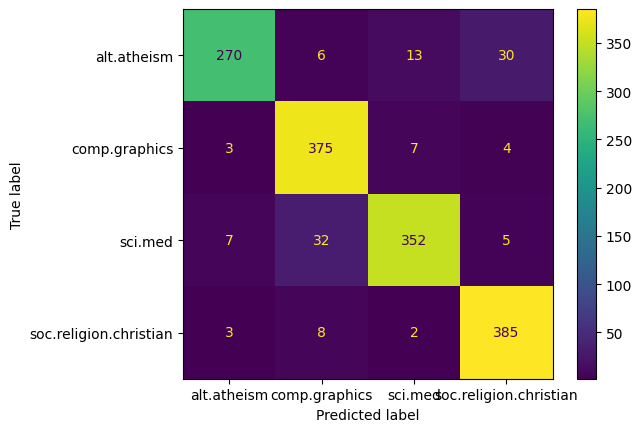

In [38]:
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=twenty_test.target_names).plot()
plt.show()

In [39]:
print(classification_report(twenty_test.target, y_hat, target_names=twenty_test.target_names))#twenty_test.target_names

                        precision    recall  f1-score   support

           alt.atheism       0.95      0.85      0.90       319
         comp.graphics       0.89      0.96      0.93       389
               sci.med       0.94      0.89      0.91       396
soc.religion.christian       0.91      0.97      0.94       398

              accuracy                           0.92      1502
             macro avg       0.92      0.92      0.92      1502
          weighted avg       0.92      0.92      0.92      1502



### 1.5 Predict some sentences
Type some sentences and check if they are predicted correctly.

In [40]:
docs_new = ['God is love', 'Lungs and heart health', "CPU or GPU?"]

predicted = best_model.predict(docs_new)

for doc, category in zip(docs_new, predicted):
    print(doc, "=>", twenty_train.target_names[category])

God is love => soc.religion.christian
Lungs and heart health => sci.med
CPU or GPU? => comp.graphics


## To go further...

Other more advanced word embedding methods can be found in recent literature, and some are available in other packages, or online in trainable or pretrained versions. 
Those include static embeddings: (see word2vec, GloVe, fastText) and context dynamic embeddings: (Transformers, BERT, GPT, ...).

A few python libraries I can recommend you look up if you're interested: `nltk`, `gensim`, the huggingface libraries, ...

## Appendix: Text wrangling and preprocessing

In practice, textual datasets are rarely clean nor well structured, and often need some wrangling and preprocessing to be used effectively. 

Furthermore, depending on the specific task and context at hand, there are often other tailor-made transformations that can prove usefull as an addition or a replacement to normalization. (E.g. the way you would like to handle the `@`symbol might differ between e-mail and social media data. Or there might be specific groups of words that have similar meaning in general, but whose differentiation is important in a specific context.)

Additionally to vectorisation, manual feature extraction can also prove useful. For example the number of exclamation marks, the number of ALL CAPS WORDS, or the average word per sentence ratio might give additional information on the tone or sentiment of written text, depending on the context and model.

Here are a few basic string methods that can come in handy for those scenarios.

In [42]:
import string

In [43]:
text = "Hi there!"
text

'Hi there!'

In [44]:
text.replace("Hi","Hello")

'Hello there!'

In [45]:
text.replace("!"," ! ")

'Hi there ! '

In [46]:
text.replace("e","")

'Hi thr!'

In [47]:
text.split(" ")

['Hi', 'there!']

In [48]:
text.lower()

'hi there!'

In [49]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

The few examples above are just to inspire you some ideas. There are many things you could think of to analyze and extract informative summaries from text data. The pandas `<pd.Series>.apply()` method can come in very handy with custom user-defined functions.

pd.Series also has a `str` subset of functions for text data. Here are a few dummy examples.

In [50]:
str_text = pd.DataFrame({"my_text":["Hi there!","My dog is cute.","i lost my wallet"]})
str_text

,my_text
0,Hi there!
1,My dog is cute.
2,i lost my wallet


In [51]:
str_text.my_text.str.capitalize()

0           Hi there!
1     My dog is cute.
2    I lost my wallet
Name: my_text, dtype: object

In [52]:
str_text.my_text.str.lower()

0           hi there!
1     my dog is cute.
2    i lost my wallet
Name: my_text, dtype: object

In [53]:
str_text.my_text.str.contains("y")

0    False
1     True
2     True
Name: my_text, dtype: bool

In [55]:
str_text.my_text.str.contains("my")

0    False
1    False
2     True
Name: my_text, dtype: bool

In [56]:
str_text.my_text.str.count("e")

0    2
1    1
2    1
Name: my_text, dtype: int64

In [57]:
str_text.my_text.str.replace("e","")

0            Hi thr!
1     My dog is cut.
2    i lost my wallt
Name: my_text, dtype: object

Many more examples in the pandas documentation.

For more complicated text processing procedures, one would usually turn to [**regular expressions**](https://en.wikipedia.org/wiki/Regular_expression), as a much more powerful tool. The [`re` module](https://docs.python.org/3/library/re.html) provides the base tools to work with regular expressions in python. Some `pandas`'s  `Series.str` methods above also accept regular expressions.

This goes beyond the scope of this seminar, but if you are interested:
- [Interactive RegEx tutorials](https://regexr.com/)
- [Another tutorial](https://www.w3schools.com/python/python_regex.asp)
- And many more...